<a href="https://colab.research.google.com/github/Darshika2004/cross-platform-spam-detector/blob/member-03-pipeline/member_03_RandomForest_BERT_Training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Cross-Platform Spam Detector

## Member 03 – G. Darshika Nuwangani

- **Machine Learning Model:** Random Forest
- **Deep Learning Model:** BERT (Bidirectional Encoder Representations from Transformers)
- **Dataset:** combined_spam_dataset.csv (SMS, Email, YouTube)

In [1]:
# Installing required libraries for BERT if not present
!pip install -q transformers torch

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# Scikit-Learn libraries
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# PyTorch and Transformers (BERT)
import torch
from transformers import BertTokenizer, BertForSequenceClassification, Trainer, TrainingArguments

# Set random seed for reproducibility
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

print(" All libraries imported successfully!")

 All libraries imported successfully!


In [2]:
# Mount Google Drive to access files
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# Load the dataset
df = pd.read_csv('/content/drive/MyDrive/combined_spam_dataset.csv')

print("--- First 5 Rows ---")
display(df.head())

print(f"\n Dataset Shape: {df.shape[0]} Rows, {df.shape[1]} Columns")

--- First 5 Rows ---


,text,label,source
0,supply quality china exclusive dimension unbea...,1,Email
1,sidlet know thx,0,Email
2,dear friend greeting wish accost request would...,1,Email
3,mr cheung puihang seng bank ltd de voeux rd br...,1,Email
4,surprising assessment embassy,0,Email



 Dataset Shape: 11818 Rows, 3 Columns


In [4]:
print("================ Data Validation Report ================")
print("\n1. Data Types and Info:")
print(df.info())

print("\n2. Missing Values Check:")
print(df.isnull().sum())

print(f"\n3. Duplicate Records Count: {df.duplicated().sum()}")

print("\n4. Label Distribution:")
print(df['label'].value_counts())

# Check for 'source' or 'platform' column
if 'source' in df.columns:
    print("\n5. Platform Distribution:")
    print(df['source'].value_counts())
elif 'platform' in df.columns:
    print("\n5. Platform Distribution:")
    print(df['platform'].value_counts())

================ Data Validation Report ================

1. Data Types and Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11818 entries, 0 to 11817
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    11818 non-null  object
 1   label   11818 non-null  int64 
 2   source  11818 non-null  object
dtypes: int64(1), object(2)
memory usage: 277.1+ KB
None

2. Missing Values Check:
text      0
label     0
source    0
dtype: int64

3. Duplicate Records Count: 1441

4. Label Distribution:
label
0    8261
1    3557
Name: count, dtype: int64

5. Platform Distribution:
source
SMS        5566
Email      4770
YouTube    1482
Name: count, dtype: int64


In [5]:
# 1. Map string labels to binary integers (ham -> 0, spam -> 1) if necessary
if df['label'].dtype == object:
    label_mapping = {'ham': 0, 'spam': 1}
    df['label'] = df['label'].str.lower().map(label_mapping)

# 2. Remove duplicate records based on text content
initial_shape = df.shape[0]
df = df.drop_duplicates(subset=['text']).reset_index(drop=True)
print(f"🧹 Removed {initial_shape - df.shape[0]} duplicate rows. New shape: {df.shape}")

# 3. Handle missing text values if any exist
df = df.dropna(subset=['text']).reset_index(drop=True)

print("\nFinal Prepared Label Distribution:")
print(df['label'].value_counts())

🧹 Removed 1458 duplicate rows. New shape: (10360, 3)

Final Prepared Label Distribution:
label
0    7403
1    2957
Name: count, dtype: int64


In [6]:
X = df['text']
y = df['label']

# Split the dataset into 80% training and 20% testing sets using stratified sampling
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=SEED,
    stratify=y
)

print(f" Data successfully split!")
print(f"Training Set Size: {len(X_train)} samples")
print(f"Testing Set Size : {len(X_test)} samples")

 Data successfully split!
Training Set Size: 8288 samples
Testing Set Size : 2072 samples


In [7]:
# Initialize TF-IDF Vectorizer with a max limit of 5000 features
tfidf = TfidfVectorizer(max_features=5000, stop_words='english')

# Fit and transform the training text data
X_train_tfidf = tfidf.fit_transform(X_train)

# Transform the testing text data
X_test_tfidf = tfidf.transform(X_test)

print("✅ TF-IDF Feature Extraction Completed!")
print(f"Training Features Shape: {X_train_tfidf.shape}")
print(f"Testing Features Shape : {X_test_tfidf.shape}")

✅ TF-IDF Feature Extraction Completed!
Training Features Shape: (8288, 5000)
Testing Features Shape : (2072, 5000)


In [8]:
# Initialize the Random Forest Classifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=SEED, n_jobs=-1)

# Train (fit) the model on the TF-IDF training features
rf_model.fit(X_train_tfidf, y_train)

print(" Random Forest Model Trained Successfully!")

 Random Forest Model Trained Successfully!


================ Random Forest Evaluation ================
Accuracy  : 96.77%
Precision : 97.46%
Recall    : 91.03%
F1 Score  : 94.14%

Detailed Classification Report:
              precision    recall  f1-score   support

     Ham (0)       0.97      0.99      0.98      1481
    Spam (1)       0.97      0.91      0.94       591

    accuracy                           0.97      2072
   macro avg       0.97      0.95      0.96      2072
weighted avg       0.97      0.97      0.97      2072



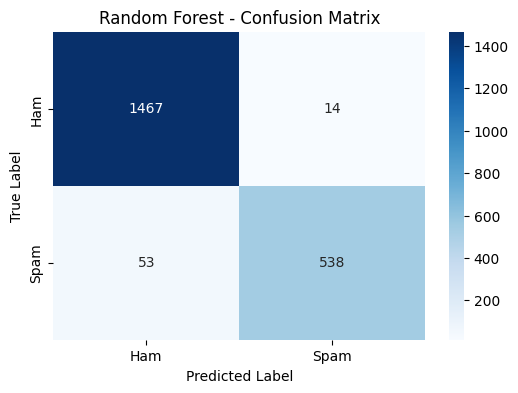

In [9]:
# Predict on testing set
y_pred_rf = rf_model.predict(X_test_tfidf)

# Calculate Evaluation Metrics
rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_precision = precision_score(y_test, y_pred_rf)
rf_recall = recall_score(y_test, y_pred_rf)
rf_f1 = f1_score(y_test, y_pred_rf)

print("================ Random Forest Evaluation ================")
print(f"Accuracy  : {rf_accuracy * 100:.2f}%")
print(f"Precision : {rf_precision * 100:.2f}%")
print(f"Recall    : {rf_recall * 100:.2f}%")
print(f"F1 Score  : {rf_f1 * 100:.2f}%\n")

print("Detailed Classification Report:")
print(classification_report(y_test, y_pred_rf, target_names=['Ham (0)', 'Spam (1)']))

# Plot Confusion Matrix
cm = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'])
plt.title('Random Forest - Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [10]:
# Load pre-trained BERT Tokenizer
MODEL_NAME = 'bert-base-uncased'
tokenizer = BertTokenizer.from_pretrained(MODEL_NAME)

# Create a custom PyTorch Dataset class for BERT
class SpamDataset(torch.utils.data.Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=128):
        self.texts = list(texts)
        self.labels = list(labels)
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = self.labels[idx]

        encoding = self.tokenizer(
            text,
            truncation=True,
            padding='max_length',
            max_length=self.max_len,
            return_tensors='pt'
        )

        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(label, dtype=torch.long)
        }

# Prepare train and test datasets for BERT
train_dataset = SpamDataset(X_train, y_train, tokenizer)
test_dataset = SpamDataset(X_test, y_test, tokenizer)

print("✅ BERT Tokenizer & Dataset Preparation Completed!")

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

✅ BERT Tokenizer & Dataset Preparation Completed!


In [11]:
# Check if GPU is available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Load pre-trained BERT Model for Sequence Classification (2 classes: Ham / Spam)
bert_model = BertForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)
bert_model.to(device)

# Define evaluation metric function for HuggingFace Trainer
def compute_metrics(p):
    preds = np.argmax(p.predictions, axis=1)
    labels = p.label_ids
    acc = accuracy_score(labels, preds)
    prec = precision_score(labels, preds)
    rec = recall_score(labels, preds)
    f1 = f1_score(labels, preds)
    return {'accuracy': acc, 'precision': prec, 'recall': rec, 'f1': f1}

# Define Training Arguments
training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=2,              # 2 Epochs are usually enough for fine-tuning BERT
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    warmup_steps=100,
    weight_decay=0.01,
    logging_dir='./logs',
    logging_steps=50,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    seed=SEED
)

# Initialize Trainer
trainer = Trainer(
    model=bert_model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics,
)

# Train the BERT model
print("Starting BERT Training...")
trainer.train()
print(" BERT Model Training Completed!")

Using device: cuda


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  440MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

...

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.162725,0.067699,0.978282,0.965870,0.957699,0.961767
2,0.074194,0.067027,0.982625,0.977625,0.961083,0.969283


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.atte

 BERT Model Training Completed!


================ BERT Evaluation ================
Accuracy  : 98.26%
Precision : 97.76%
Recall    : 96.11%
F1 Score  : 96.93%

Detailed Classification Report:
              precision    recall  f1-score   support

     Ham (0)       0.98      0.99      0.99      1481
    Spam (1)       0.98      0.96      0.97       591

    accuracy                           0.98      2072
   macro avg       0.98      0.98      0.98      2072
weighted avg       0.98      0.98      0.98      2072



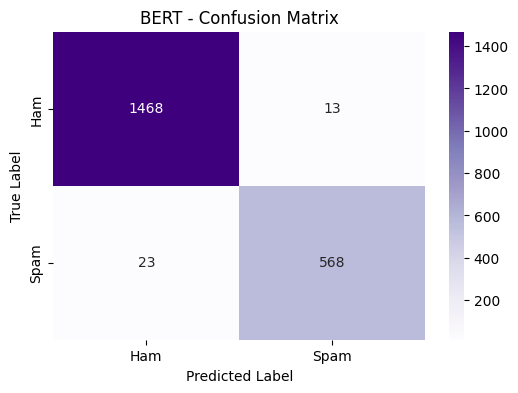

In [12]:
# Make predictions on test set
predictions = trainer.predict(test_dataset)
y_pred_bert = np.argmax(predictions.predictions, axis=1)

# Calculate Evaluation Metrics
bert_accuracy = accuracy_score(y_test, y_pred_bert)
bert_precision = precision_score(y_test, y_pred_bert)
bert_recall = recall_score(y_test, y_pred_bert)
bert_f1 = f1_score(y_test, y_pred_bert)

print("================ BERT Evaluation ================")
print(f"Accuracy  : {bert_accuracy * 100:.2f}%")
print(f"Precision : {bert_precision * 100:.2f}%")
print(f"Recall    : {bert_recall * 100:.2f}%")
print(f"F1 Score  : {bert_f1 * 100:.2f}%\n")

print("Detailed Classification Report:")
print(classification_report(y_test, y_pred_bert, target_names=['Ham (0)', 'Spam (1)']))

# Plot Confusion Matrix
cm_bert = confusion_matrix(y_test, y_pred_bert)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_bert, annot=True, fmt='d', cmap='Purples', xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'])
plt.title('BERT - Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [13]:
import os
import joblib

# Set Google Drive base path (Make sure Drive is mounted via Section 3)
DRIVE_MODELS_PATH = '/content/drive/MyDrive/spam_detection/models'

# Create the models directory inside your Google Drive if it doesn't exist
os.makedirs(DRIVE_MODELS_PATH, exist_ok=True)

# 1. Save Random Forest Model & TF-IDF Vectorizer to Drive
joblib.dump(rf_model, os.path.join(DRIVE_MODELS_PATH, 'random_forest.pkl'))
joblib.dump(tfidf, os.path.join(DRIVE_MODELS_PATH, 'tfidf_vectorizer.pkl'))
print(f" Random Forest model & TF-IDF Vectorizer saved to Google Drive: {DRIVE_MODELS_PATH}")

# 2. Save BERT Model & Tokenizer to Drive
bert_save_path = os.path.join(DRIVE_MODELS_PATH, 'bert_model')
bert_model.save_pretrained(bert_save_path)
tokenizer.save_pretrained(bert_save_path)
print(f" BERT model & Tokenizer saved to Google Drive: {bert_save_path}")

 Random Forest model & TF-IDF Vectorizer saved to Google Drive: /content/drive/MyDrive/spam_detection/models


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

 BERT model & Tokenizer saved to Google Drive: /content/drive/MyDrive/spam_detection/models/bert_model
